In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
trades = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

print(trades.shape)
print(fg.shape)
trades.head()

(211224, 16)
(2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:

trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = pd.to_datetime(trades['datetime'].dt.date)

fg['date'] = pd.to_datetime(fg['date'])

print(trades['date'].min(), "to", trades['date'].max())
print(fg['date'].min(), "to", fg['date'].max())

2023-05-01 00:00:00 to 2025-05-01 00:00:00
2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [4]:
df = trades.merge(fg[['date', 'value', 'classification']], on='date', how='left')
df = df.rename(columns={'classification': 'sentiment', 'value': 'fg_value'})
df = df.dropna(subset=['sentiment'])

print(df.shape)
df['sentiment'].value_counts()

(211218, 20)


sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [5]:
sent_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

closing = df[df['Closed PnL'] != 0]

summary = df.groupby('sentiment').agg(
    total_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'size')
).reindex(sent_order)

summary['avg_pnl_per_close'] = closing.groupby('sentiment')['Closed PnL'].mean()
summary['win_rate_%'] = closing.groupby('sentiment')['Closed PnL'].apply(lambda x: (x > 0).mean() * 100)

summary.round(2)

,total_pnl,trade_count,avg_pnl_per_close,win_rate_%
sentiment,,,,
Extreme Fear,739110.25,21400,71.03,76.22
Fear,3357155.44,61837,112.63,87.29
Neutral,1292920.68,37686,71.20,82.39
Greed,2150129.27,50303,85.40,76.89
Extreme Greed,2715171.31,39992,130.21,89.17


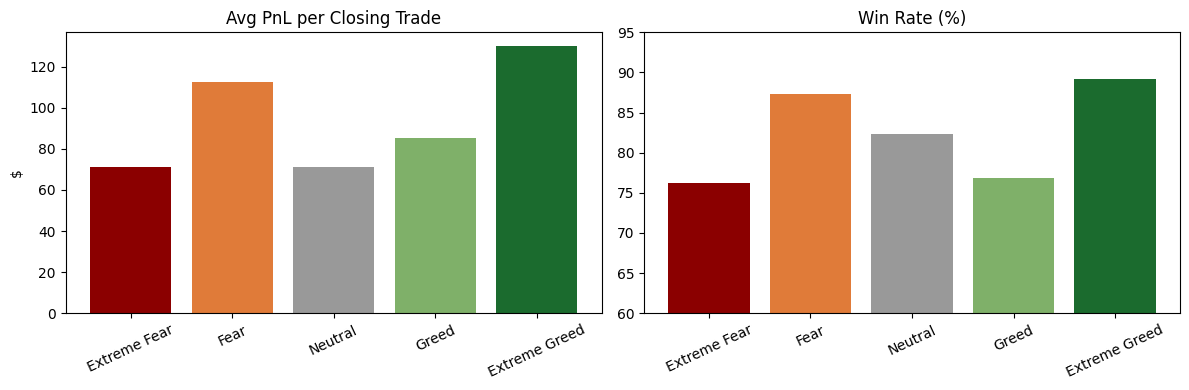

In [6]:
colors = ['#8b0000', '#e07b39', '#999999', '#7fb069', '#1b6b2e']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(sent_order, summary['avg_pnl_per_close'], color=colors)
axes[0].set_title('Avg PnL per Closing Trade')
axes[0].set_ylabel('$')

axes[1].bar(sent_order, summary['win_rate_%'], color=colors)
axes[1].set_title('Win Rate (%)')
axes[1].set_ylim(60, 95)

for ax in axes:
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('chart1_pnl_by_sentiment.png')
plt.show()

In [7]:
behavior = df.groupby('sentiment').agg(
    avg_size_usd=('Size USD', 'mean')
).reindex(sent_order)

behavior['buy_ratio'] = df.groupby('sentiment')['Side'].apply(lambda s: (s == 'BUY').mean())

behavior.round(3)

,avg_size_usd,buy_ratio
sentiment,,
Extreme Fear,5349.732,0.511
Fear,7816.110,0.490
Neutral,4782.733,0.503
Greed,5736.884,0.489
Extreme Greed,3112.252,0.449


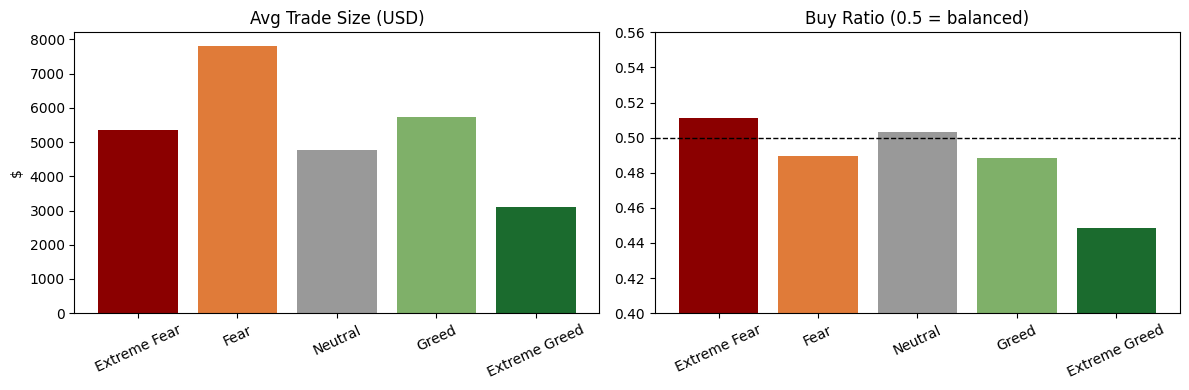

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(sent_order, behavior['avg_size_usd'], color=colors)
axes[0].set_title('Avg Trade Size (USD)')
axes[0].set_ylabel('$')

axes[1].bar(sent_order, behavior['buy_ratio'], color=colors)
axes[1].axhline(0.5, ls='--', color='black', lw=1)
axes[1].set_title('Buy Ratio (0.5 = balanced)')
axes[1].set_ylim(0.40, 0.56)

for ax in axes:
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('chart2_behavior.png')
plt.show()

In [9]:
closes = df[df['Direction'].isin(['Close Long', 'Close Short'])]

long_short = closes.groupby(['sentiment', 'Direction'])['Closed PnL'].mean().unstack().reindex(sent_order)

long_short.round(2)

Direction,Close Long,Close Short
sentiment,,
Extreme Fear,81.20,123.40
Fear,83.00,207.68
Neutral,52.82,94.80
Greed,88.96,55.20
Extreme Greed,61.83,28.97


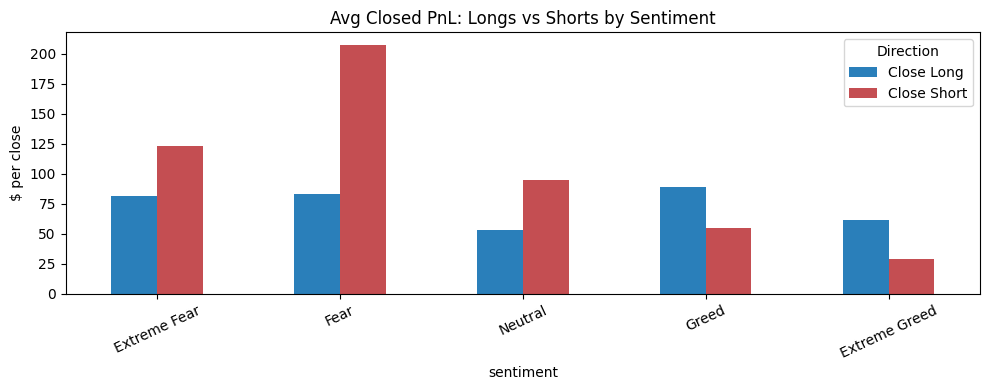

In [10]:
ax = long_short.plot(kind='bar', figsize=(10, 4), color=['#2a7fba', '#c44e52'])
ax.set_title('Avg Closed PnL: Longs vs Shorts by Sentiment')
ax.set_ylabel('$ per close')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('chart3_long_short.png')
plt.show()

In [11]:
accounts = df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    trades=('Closed PnL', 'size')
).sort_values('total_pnl', ascending=False)

print("Profitable accounts:", (accounts['total_pnl'] > 0).sum(), "of", len(accounts))
accounts.head(10).round(0)

Profitable accounts: 29 of 32


,total_pnl,trades
Account,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2143383.0,14733
0x083384f897ee0f19899168e3b1bec365f52a9012,1600230.0,3818
0xbaaaf6571ab7d571043ff1e313a9609a10637864,940164.0,21192
0x513b8629fe877bb581bf244e326a047b249c4ff1,840423.0,12236
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,836081.0,40184
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,677747.0,4356
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,429356.0,1590
0x430f09841d65beb3f27765503d0f850b8bce7713,416542.0,1237
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,379095.0,9893


In [12]:
top5 = accounts.index[:5]
bot5 = accounts.index[-5:]

rows = []
for label, accs in [('Top 5', top5), ('Bottom 5', bot5)]:
    sub = df[df['Account'].isin(accs)]
    fear = sub[sub['sentiment'].isin(['Fear', 'Extreme Fear'])]
    greed = sub[sub['sentiment'].isin(['Greed', 'Extreme Greed'])]
    rows.append({
        'group': label,
        'buy_ratio_fear': (fear['Side'] == 'BUY').mean(),
        'buy_ratio_greed': (greed['Side'] == 'BUY').mean()
    })

pd.DataFrame(rows).round(3)

,group,buy_ratio_fear,buy_ratio_greed
0,Top 5,0.499,0.407
1,Bottom 5,0.402,0.647


In [13]:
daily = df.groupby('date').agg(daily_pnl=('Closed PnL', 'sum')).reset_index()
daily = daily.merge(fg[['date', 'value', 'classification']], on='date', how='left')
daily = daily.rename(columns={'classification': 'sentiment'})


daily['prev_sentiment'] = daily['sentiment'].shift(1)

lag = daily.groupby('prev_sentiment')['daily_pnl'].agg(['mean', 'median', 'count']).reindex(sent_order)
lag.round(0)

,mean,median,count
prev_sentiment,,,
Extreme Fear,72701.0,26491.0,14
Fear,35152.0,1412.0,91
Neutral,13713.0,1144.0,66
Greed,13213.0,757.0,193
Extreme Greed,22655.0,3128.0,114


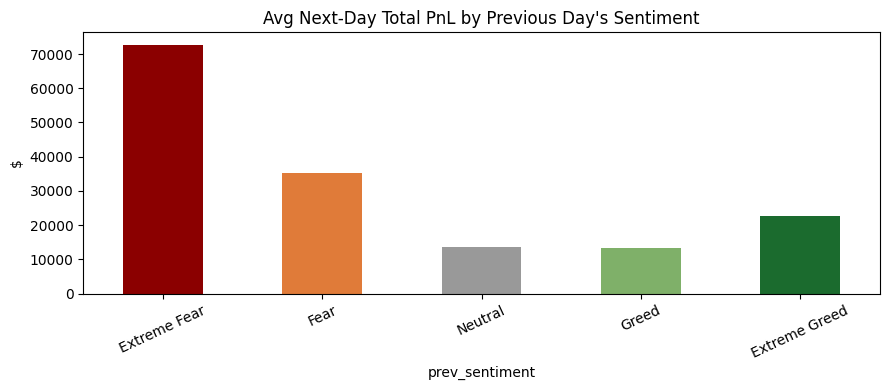

In [14]:
ax = lag['mean'].plot(kind='bar', figsize=(9, 4), color=colors)
ax.set_title("Avg Next-Day Total PnL by Previous Day's Sentiment")
ax.set_ylabel('$')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('chart4_lagged.png')
plt.show()

## Key Insights

1. Trades during sentiment extremes performed better than calm markets. Average PnL per
   closing trade was highest in Extreme Greed (~$130) and Fear (~$113), with win rates of
   89% and 87%. Neutral days were the weakest (~$71 avg, 82% win rate).

2. The side that makes money flips with sentiment. In Fear, short closes averaged $208 vs
   only $83 for longs. In Greed it reverses — longs averaged $89 vs $55 for shorts. So
   shorting worked in fearful markets and going long worked in greedy markets.

3. The best and worst traders behave in opposite ways. The top 5 accounts mostly sell
   during Greed (buy ratio 0.41), while the bottom 5 buy 65% of the time during Greed and
   only 40% during Fear. In short, the losing accounts buy tops and sell bottoms.

4. Trade sizes are much bigger during Fear (~$7,800 avg) than Extreme Greed (~$3,100).
   Traders put about 2.5x more money to work when the market is fearful, which looks like
   dip buying.

5. Days right after an Extreme Fear reading were the most profitable overall (~$72,700
   avg total PnL vs ~$13,200 after Greed days). But there are only 14 such days in the
   data, so this is a small sample.

## Strategy Recommendations

- Use the daily Fear & Greed reading as a direction filter: prefer shorts in Fear regimes
  and longs in Greed regimes, since that's where each side actually made money.
- Consider sizing up for 1-3 days after an Extreme Fear reading those were the best days
  in the dataset.
- Track your own buy ratio per regime. Buying more than ~60% of the time during Greed
  matches the pattern of the worst accounts.

## Limitations

- Only 32 accounts, so this shows the behavior of this group, not the whole market.
- The brief mentions a leverage column but the file doesn't have one, so I used Size USD
  as the risk measure instead.
- Closed PnL counts on the closing date, not over the holding period.
- The Extreme Fear lag result is based on just 14 days.